# 3) Extracting and comparing 1D columns from your models

In this notebook, we want to take a look at how to extract information from your geophysical models at a certain point along the profile.

For this, we make use of simple interpolation and visualization functions, either integrated in pyGIMLi or accessible via Matplotlib or NumPy. 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
from matplotlib.colors import Normalize, LogNorm

We start by defining a small function to generate interpolated values at a certain x-position along our measured transects.

For this, we require a x- and y-space with a pre-defined number of points as well as our model and the corresponding mesh:

In [ ]:
def generate_virtual_borehole(mesh, model, x_coord, n=500):

    y_min = mesh.ymin()
    y_max = mesh.ymax()

    y = np.linspace(y_min, y_max, n)
    x = np.ones_like(y) * x_coord

    values = pg.interpolate(srcMesh=mesh, inVec=model, x=x, y=y)
    return values, y

We start by loading both saved inverse models that we exported as VTK files.

As discussed before, the exported VTK file holds i) the mesh and ii) the resistivity or traveltime data.

Thus, we already have everything we require for our interpolation:

In [49]:
inv_ert = pg.load("inv_ERT.vtk")
inv_srt = pg.load("inv_SRT.vtk") 

inv_ert

Mesh: Nodes: 1780 Cells: 3315 Boundaries: 5094
Mesh contains data: Marker, Resistivity

## 3.1) Generate 1D line plots

In [79]:
x_coord = 50

y_ERT = np.linspace(inv_ert.ymin(), inv_ert.ymax(),500)
# x_ERT = np.ones_like(y_ERT)*x_coord

y_SRT = np.linspace(inv_ert.ymin(), inv_ert.ymax(),500)
# x_SRT = np.ones_like(y_SRT)*x_coord


# ERT_1D = pg.interpolate(srcMesh=inv_ert, inVec=inv_ert["Resistivity"], x=x_ERT, y=y_ERT)
# SRT_1D = pg.interpolate(srcMesh=inv_srt, inVec=inv_srt["Traveltime"], x=x_SRT, y=y_SRT)

ERT_1D, y_ERT = generate_virtual_borehole(inv_ert, inv_ert["Resistivity"], x_coord, n=500)
SRT_1D, y_SRT = generate_virtual_borehole(inv_srt, inv_srt["Traveltime"], x_coord, n=500)

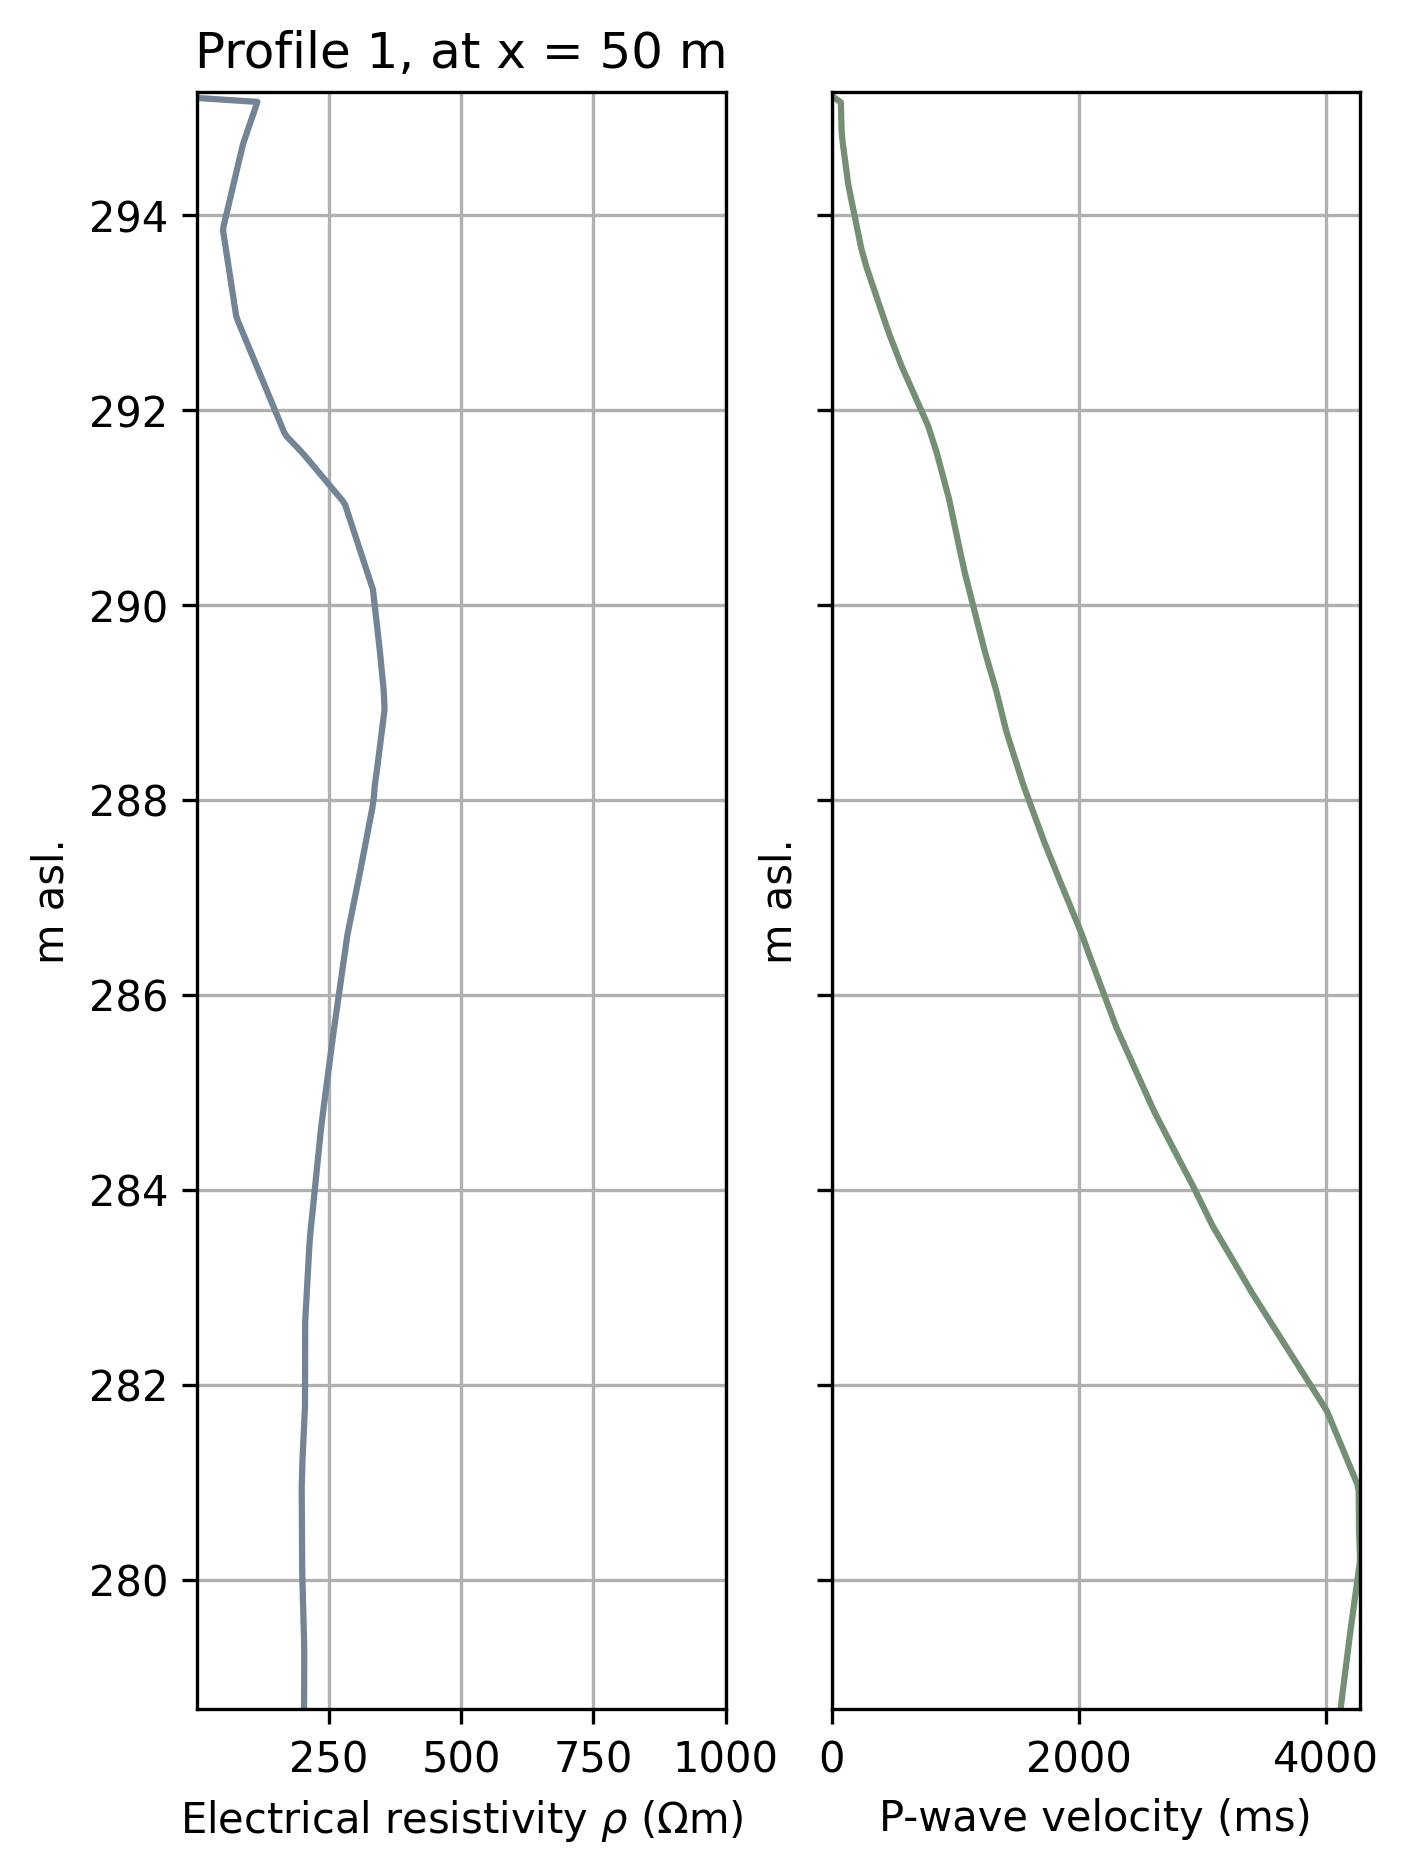

In [ ]:
# find lower and upper valid, nonzero values:
 
first, last = np.flatnonzero(ERT_1D)[[0, -1]]
lower_Y = y_ERT[first]
upper_Y = y_ERT[last]

colors = ["#738494", "#748f73"]

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(5, 7), sharey=True, dpi=300
)

# ERT profile
ax1.plot(ERT_1D, y_ERT, color=colors[0])
ax1.set_ylabel("m asl.")
ax1.set_title(f"Profile 1, at x = {x_coord} m")
ax1.set_xlim(2.5, 1000)
ax1.set_ylim(upper_Y, lower_Y)
ax1.set_xlabel(r"Electrical resistivity $\rho$ ($\Omega \text{m}$)")
ax1.grid(True)

# SRT profile
ax2.plot(SRT_1D, y_SRT, color=colors[1])
ax2.set_ylabel("m asl.")
ax2.set_xlabel("P-wave velocity (ms)")
ax2.set_xlim(np.nanmin(SRT_1D), np.nanmax(SRT_1D))
ax2.set_ylim(lower_Y, upper_Y+.1)
ax2.grid(True)

# fig.tight_layout()

In [100]:
x_coord = 50

y_ERT = np.linspace(inv_ert.ymin(), inv_ert.ymax(),500)
x_ERT = np.ones_like(y_ERT)*x_coord

y_SRT = np.linspace(inv_ert.ymin(), inv_ert.ymax(),500)
x_SRT = np.ones_like(y_SRT)*x_coord


ERT_1D = pg.interpolate(srcMesh=inv_ert, inVec=inv_ert["Resistivity"], x=x_ERT, y=y_ERT)
SRT_1D = pg.interpolate(srcMesh=inv_srt, inVec=inv_srt["Traveltime"], x=x_SRT, y=y_SRT)

## 3.2) Color-coded 1D column ("virtual borehole") plots

Instead of a line plot, we can display the interpolated 1D profile as a color-coded vertical
column, similar to a borehole log.

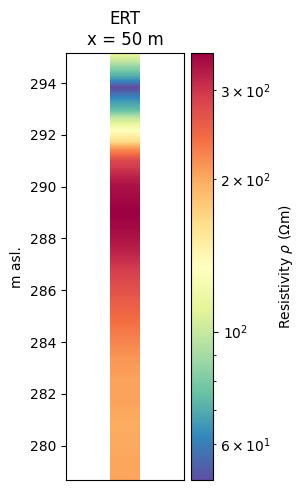

In [101]:
order = np.argsort(y_ERT)[::-1]
y_sorted = y_ERT[order]
values_sorted = np.asarray(ERT_1D)[order]

# drop invalid samples (e.g. outside the mesh) at the top/bottom of the profile
valid = np.isfinite(values_sorted) & (values_sorted != 0)
first, last = np.flatnonzero(valid)[[0, -1]]
y_sorted = y_sorted[first:last + 1]
values_sorted = values_sorted[first:last + 1]

# single "layers" have to be given as thicknesses starting from the topmost layer:
thk = -np.diff(y_sorted)  
ztopo = y_sorted[0]      

fig, ax1 = plt.subplots(1, 1, figsize=(3, 5))

col = pg.viewer.mpl.draw1DColumn(
    ax=ax1,
    x=0.,
    val=values_sorted,
    thk=thk,
    width=0.25,
    ztopo=ztopo,
    cMin=np.nanmin(values_sorted),
    cMax=np.nanmax(values_sorted),
    cMap="Spectral_r",
    logScale=True,
)

ax1.set_xlim(-0.5, 0.5)
ax1.set_ylim(y_sorted[-1], y_sorted[0])
ax1.set_xticks([])
ax1.set_ylabel("m asl.")
ax1.set_title(f"ERT\nx = {x_coord} m")

cbar = fig.colorbar(col, ax=ax1)
cbar.set_label(r"Resistivity $\rho$ ($\Omega$m)")

fig.tight_layout()